<h1>Leaf Disease Classification - Keras CNN .. With 96% Accuracy</h1>
<img 
style="width : 100%;margin: auto;"    
src="https://www.google.com/search?q=leaf+disease&sxsrf=ALiCzsb-Fr5LvT82eoxXJt3fDQmP8Qo_cA:1654161628719&source=lnms&tbm=isch&sa=X&ved=2ahUKEwiGpZ-iuI74AhVKBaYKHYEJBIMQ_AUoAXoECAIQAw&biw=1707&bih=806&dpr=1.13#imgrc=BJHS-ZYd7zmuTM&imgdii=O8NuCBPDZa8ipM>

# 1. Import Libraries

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import itertools

from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory, image
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import load_model

from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(0)
np.random.seed(0)



# 2. Check Dataset Path

In [7]:
base_path = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

print(os.listdir(base_path))

['valid', 'train']


# 3. Load Dataset

In [8]:
train_gen = image_dataset_from_directory(
    directory=base_path + "/train",
    image_size=(256, 256)
)

test_gen = image_dataset_from_directory(
    directory=base_path + "/valid",
    image_size=(256, 256)
)


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [21]:
class_names = sorted(os.listdir(base_path + "/train"))

# 4. Normalize Data


In [11]:
rescale = Rescaling(1.0/255)

train_gen = train_gen.map(lambda x, y: (rescale(x), y))
test_gen = test_gen.map(lambda x, y: (rescale(x), y))


# 5. Build CNN Model

In [14]:
model = keras.Sequential()

# Block 1
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 2
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 3
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 4
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Dense
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512,activation="relu"))
model.add(keras.layers.Dropout(0.5))

# Output
model.add(keras.layers.Dense(38,activation="softmax"))

<h1>Data Loading</h1>
<p>Setting up Image Data Generators<p>

## 6. Compile Model


In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_16 (Conv2D)           (None, 256, 256, 32)      896       
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 256, 256, 32)      9248      
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 128, 128, 32)      0         
_________________________________________________________________
conv2d_18 (Conv2D)           (None, 128, 128, 64)      18496     
_________________________________________________________________
conv2d_19 (Conv2D)           (None, 128, 128, 64)      36928     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_20 (Conv2D)           (None, 64, 64, 128)      

<h1>Data Engineering</h1>
<p>Since the data is already augmented, there is no requirement of data engineering. Feature scaling is automatically done by image generators</p>

<h1>Modelling</h1>

## 7. Train Model

In [17]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)


Epoch 1/10
2197/2197 [==============================] - 230s 100ms/step - loss: 3.6372 - accuracy: 0.0287 - val_loss: 3.6364 - val_accuracy: 0.0287
Epoch 2/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6367 - accuracy: 0.0291 - val_loss: 3.6361 - val_accuracy: 0.0287
Epoch 3/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6364 - accuracy: 0.0289 - val_loss: 3.6361 - val_accuracy: 0.0286
Epoch 4/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6364 - accuracy: 0.0283 - val_loss: 3.6360 - val_accuracy: 0.0287
Epoch 5/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6363 - accuracy: 0.0296 - val_loss: 3.6360 - val_accuracy: 0.0287
Epoch 6/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6363 - accuracy: 0.0286 - val_loss: 3.6360 - val_accuracy: 0.0287
Epoch 7/10
2197/2197 [==============================] - 212s 96ms/step - loss: 3.6362 - accuracy: 0.0282 - val_loss: 

## Testing Model on Sample Images (First 15 Images)

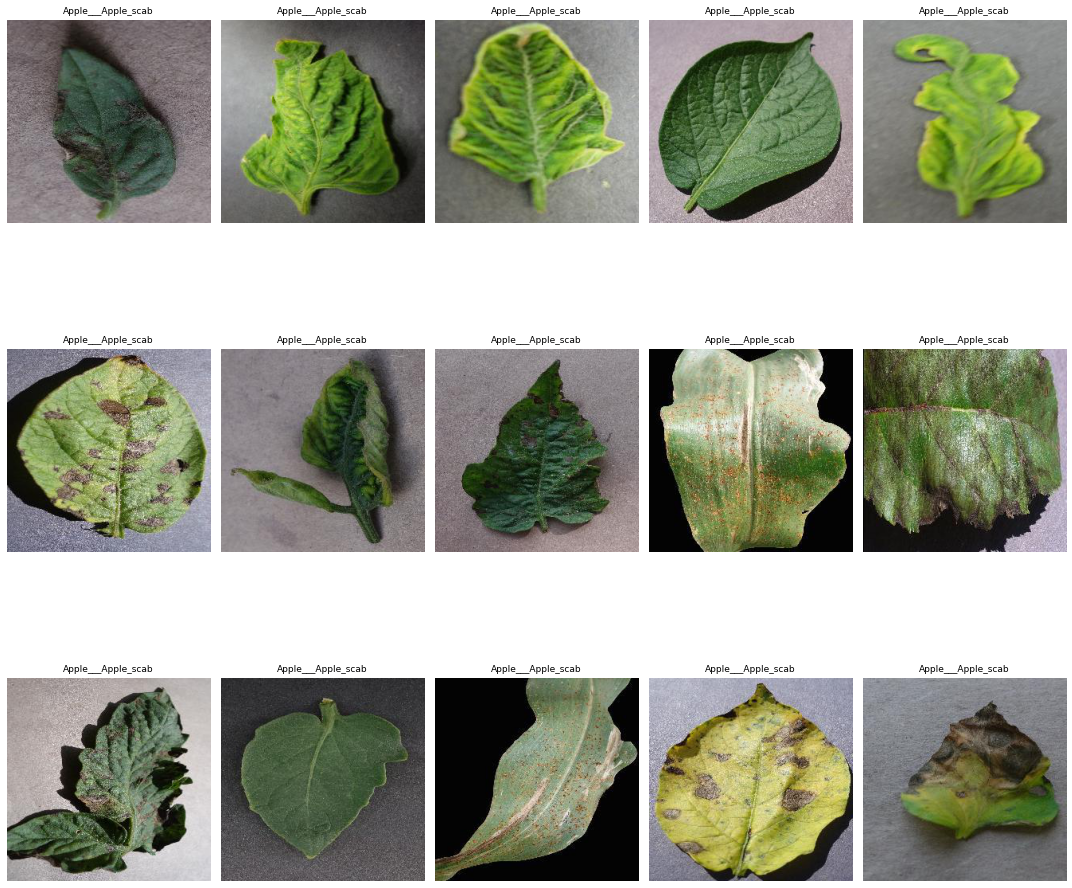

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ✅ FIX
class_names = sorted(os.listdir(base_path + "/train"))

folder_path = "/kaggle/input/new-plant-diseases-dataset/test/test"

plt.figure(figsize=(15,15))

for i, img_name in enumerate(os.listdir(folder_path)[:15]):

    img_path = os.path.join(folder_path, img_name)

    img = image.load_img(img_path, target_size=(256,256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    pred = model.predict(img_array, verbose=0)
    label = class_names[np.argmax(pred)]

    plt.subplot(3,5,i+1)
    plt.imshow(img)
    plt.title(label, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 9. Load Model


In [26]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'cnn_model.h5']


In [27]:
model = load_model("/kaggle/working/cnn_model.h5")

# 10. Test on Single Image

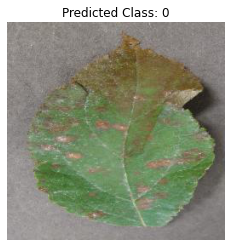

In [28]:
img_path = "/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust4.JPG"

img = image.load_img(img_path, target_size=(256,256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)
pred_class = np.argmax(pred)

plt.imshow(img)
plt.title(f"Predicted Class: {pred_class}")
plt.axis("off")
plt.show()


# 11. Evaluate Model

In [29]:
labels = []
predictions = []

for x, y in test_gen:
    preds = model.predict(x, verbose=0)
    
    labels.extend(y.numpy())
    predictions.extend(tf.argmax(preds, axis=1).numpy())


# 12. Metrics

In [30]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))


Train Accuracy  : 2.92 %
Test Accuracy   : 2.87 %
Precision Score : 2.87 %
Recall Score    : 2.87 %


# 13. Confusion Matrix

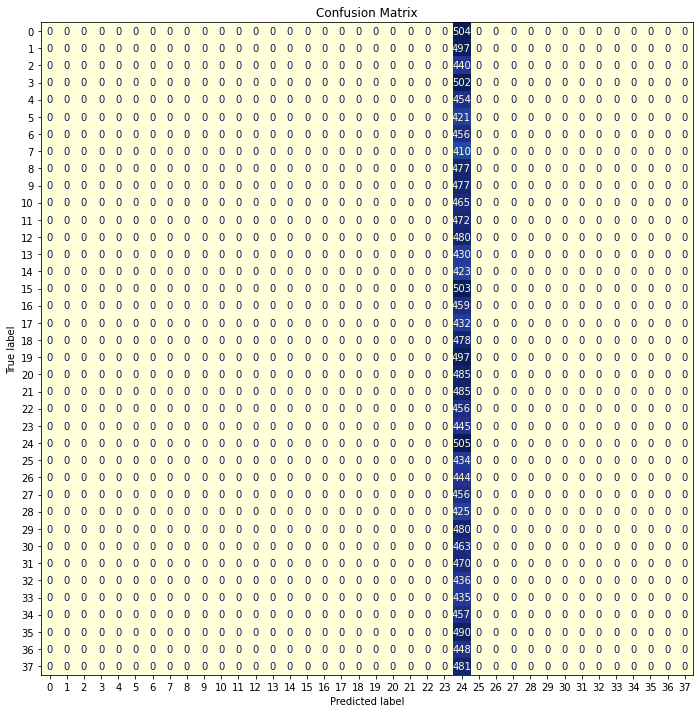

In [31]:
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(38))
)

fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax, cmap="YlGnBu", colorbar=False)

plt.title("Confusion Matrix")
plt.show()

# Save Model

In [32]:

model.save("/kaggle/working/cnn_model.h5")
print("Saved successfully")


Saved successfully
